# Drift Synthetic as Plants — V3 (redux, single-pass, full timeline)

**Qué cambia vs V3 anterior:**
- Se elimina el colapso **diario** y la duplicación de `compare_with_metrics`.
- La detección se hace a **resolución nativa** del DataFrame (p. ej., por hora si tus datos son horarios).
- Visualizaciones inline:
  - 10 series con **sombreado (verdad)** al estilo V2 + **líneas** donde detectan los métodos.
  - Heatmap de verdad (tiempo×variable) y heatmap **combinado** (0=ninguno, 1=verdad, 2=pred, 3=ambos).
  - 12 heatmaps (solo detección) por cada combinación **estrategia×método**.

Puedes reemplazar la sección de **Datos sintéticos** por tus datos reales (`df_wide` + `truth_long`).

In [1]:
# ==================== Configuración ====================
TIME_COL       = 'timestamp'
TRUE_LABEL_COL = 'drift_label'

# Sintético (puedes comentar esto y cargar tu df_wide y truth_long reales)
N_VARIABLES = 20
FREQ        = 'H'       # frecuencia temporal (H = horas)
N_DAYS      = 60
SEED        = 42

# Detección
METHODS      = ['ks','mannwhitney','psi','wasserstein']
STRATEGIES   = ['decay','golden','seasonal']
REF_WINDOW   = '3D'       # ventana de referencia para decay; golden/seasonal definen su propia referencia
CUR_WINDOW   = '24H'      # ventana de comparación "actual" por timestamp
STEP         = '1H'       # stride temporal de evaluación (usa tu granularidad)

# Parámetros de métodos
ALPHA      = 0.05
MIN_EFFECT = 0.05
PSI_BINS   = 10
PSI_THR    = 0.2
WD_THR     = 0.3


In [2]:
# ==================== Librerías y utilidades ====================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from dataclasses import dataclass, asdict
from typing import List, Dict, Optional
from pandas.tseries.frequencies import to_offset
from scipy.stats import ks_2samp, mannwhitneyu, wasserstein_distance

np.random.seed(SEED)

def _date_range_hours(n_days: int, freq: str = 'H'):
    return pd.date_range(start='2024-01-01', periods=n_days*24 if freq=='H' else n_days, freq=freq)

def _inject_drift(signal: np.ndarray, episodes):
    x = signal.copy()
    for s, e, t, mag in episodes:
        if t == 'mean_shift':
            x[s:e] += mag
        elif t == 'scale':
            x[s:e] *= (1.0 + mag)
        elif t == 'trend':
            L = e - s
            x[s:e] += np.linspace(0, mag, L)
    return x

def _rand_episodes(n_points: int, max_eps: int = 3, min_len: int = 24, max_len: int = 96):
    n_eps = np.random.randint(1, max_eps+1)
    out = []
    for _ in range(n_eps):
        L = np.random.randint(min_len, max_len+1)
        start = np.random.randint(0, max(1, n_points - L))
        end = start + L
        t = np.random.choice(['mean_shift','scale','trend'], p=[0.5,0.3,0.2])
        mag = float(np.random.uniform(0.5, 2.0)) if t!='trend' else float(np.random.uniform(1.0, 4.0))
        out.append((start, end, t, mag))
    return out


In [3]:
# ==================== Datos sintéticos (puedes reemplazar por reales) ====================
def generate_synth(n_vars: int, n_days: int, freq: str = 'H'):
    ts = _date_range_hours(n_days, freq)
    n = len(ts)
    base = {}
    episodes_map = {}
    for i in range(n_vars):
        noise = np.random.normal(0, 1.0, size=n)
        x = np.zeros(n); phi = 0.8
        for t in range(1, n):
            x[t] = phi*x[t-1] + noise[t]
        x = (x - x.mean()) / (x.std() + 1e-6)
        eps = _rand_episodes(n, 3, 24, 96)
        y = _inject_drift(x, eps)
        base[f'var_{i+1}'] = y
        episodes_map[f'var_{i+1}'] = eps
    df_wide = pd.DataFrame(base, index=ts).reset_index().rename(columns={'index': TIME_COL})
    rows = []
    for v, eps in episodes_map.items():
        mask = np.zeros(n, dtype=int)
        for s,e,_,_ in eps:
            mask[s:e] = 1
        for i,t in enumerate(ts):
            rows.append({TIME_COL: t, 'variable': v, TRUE_LABEL_COL: int(mask[i])})
    truth_long = pd.DataFrame(rows)
    return df_wide, truth_long

df_wide, truth_long = generate_synth(N_VARIABLES, N_DAYS, FREQ)
VALUE_COLS = [c for c in df_wide.columns if c != TIME_COL]
df_wide.head()


C:\Users\frncc\AppData\Local\Temp\ipykernel_31040\880043084.py:11: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  return pd.date_range(start='2024-01-01', periods=n_days*24 if freq=='H' else n_days, freq=freq)


,timestamp,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,...,var_11,var_12,var_13,var_14,var_15,var_16,var_17,var_18,var_19,var_20
0,2024-01-01 00:00:00,-0.116570,-0.074260,0.023334,0.086818,-0.107900,-0.048303,0.005516,0.088748,0.110137,...,-0.021137,-0.099033,-0.088336,-0.063188,-0.008121,0.045285,-0.001011,-0.034598,0.008072,-0.036624
1,2024-01-01 01:00:00,-0.200774,0.290538,1.191219,-0.489972,-0.016880,0.289158,-0.457658,0.876768,0.743313,...,-0.311970,-0.730522,-0.539813,-0.559724,0.253110,0.198047,-0.582036,-0.830474,-0.831358,0.077583
2,2024-01-01 02:00:00,0.210514,0.987959,1.670631,0.615700,0.781683,-0.132319,-0.105378,0.301322,-0.032659,...,0.316667,-0.225282,-0.775995,-1.182482,0.851877,0.235464,-0.009121,-1.549797,-1.071691,-0.456075
3,2024-01-01 03:00:00,1.072634,0.788749,1.814158,0.531054,0.672902,0.815363,0.455402,1.377236,0.059656,...,0.620003,-0.044161,-1.202562,-0.253078,0.896532,-0.321329,0.032814,-1.258988,-1.328574,-1.629827
4,2024-01-01 04:00:00,0.692192,0.808283,1.538842,0.507898,0.564300,-0.024484,1.121453,0.716786,-0.602536,...,0.837437,-0.056904,-1.190619,0.699018,0.573120,-0.885843,-0.449353,-1.464732,-0.327698,-1.196347


In [4]:
# ==================== Ventanas por timestamp (estrategias) ====================
def _mask_between(df, col, start, end):
    return (df[col] >= start) & (df[col] < end)

def _ref_cur_masks(df, t_end, cur_window: str, strategy: str, ref_window: str):
    # ventana actual: [t_end - cur_window, t_end)
    cur_delta = to_offset(cur_window).delta or pd.to_timedelta(cur_window)
    cur_start = pd.to_datetime(t_end) - cur_delta
    cur_mask = _mask_between(df, TIME_COL, cur_start, t_end)

    if strategy == 'golden':
        # primeros 7 días del dataset
        start = pd.to_datetime(df[TIME_COL].min()).normalize()
        end = start + pd.Timedelta(days=7)
        ref_mask = _mask_between(df, TIME_COL, start, end)
        return ref_mask, cur_mask

    if strategy == 'seasonal':
        # mismo día de la semana anterior (±cur_window alrededor de t_of_day)
        # tomamos 4 semanas hacia atrás y unimos
        t = pd.to_datetime(t_end)
        ref_mask = None
        for k in range(1,5):
            ref_end_k = t - pd.Timedelta(days=7*k)
            ref_start_k = ref_end_k - cur_delta
            m = _mask_between(df, TIME_COL, ref_start_k, ref_end_k)
            ref_mask = m if ref_mask is None else (ref_mask | m)
        if ref_mask is None:
            ref_mask = pd.Series(False, index=df.index)
        return ref_mask, cur_mask

    # decay: referencia inmediatamente anterior de longitud ref_window
    ref_delta = to_offset(ref_window).delta or pd.to_timedelta(ref_window)
    ref_start = cur_start - ref_delta
    ref_end   = cur_start
    ref_mask = _mask_between(df, TIME_COL, ref_start, ref_end)
    return ref_mask, cur_mask


In [5]:
# ==================== Detectores por timestamp ====================
def ks_at(ref, cur, alpha=0.05, min_eff=0.05):
    if len(ref)<10 or len(cur)<10: return False, 0.0
    stat, p = ks_2samp(ref, cur, alternative='two-sided', mode='auto')
    return (p < alpha and stat >= min_eff), stat

def mwu_at(ref, cur, alpha=0.05):
    if len(ref)<10 or len(cur)<10: return False, 1.0
    stat, p = mannwhitneyu(ref, cur, alternative='two-sided')
    return (p < alpha), 1.0 - p  # score invertido para ordenar

def psi_val(ref, cur, bins=10):
    lo = np.nanmin([ref.min(), cur.min()]); hi = np.nanmax([ref.max(), cur.max()])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo==hi: return 0.0
    edges = np.linspace(lo, hi, bins+1)
    def hp(x):
        h,_ = np.histogram(x, bins=edges)
        p = h/ max(1,h.sum()); p = np.clip(p,1e-6,None); p = p/p.sum(); return p
    pr, pc = hp(ref), hp(cur)
    return float(np.sum((pc-pr)*np.log(pc/pr)))

def wdist_val(ref, cur):
    return float(wasserstein_distance(ref, cur))


In [6]:
# ==================== Motor único de detección (resolución nativa) ====================
@dataclass
class Event:
    variable: str
    method: str
    strategy: str
    t_end: pd.Timestamp
    score: float

def run_detection_fulltime(df_wide: pd.DataFrame,
                           value_cols: List[str],
                           methods: List[str],
                           strategies: List[str],
                           ref_window: str,
                           cur_window: str,
                           step: str,
                           params: Dict[str,dict]):
    times = pd.to_datetime(df_wide[TIME_COL]).sort_values().unique()
    step_delta = to_offset(step).delta or pd.to_timedelta(step)
    t_grid = pd.date_range(times.min(), times.max(), freq=step)
    events = []
    for strat in strategies:
        for m in methods:
            for t_end in t_grid:
                ref_mask, cur_mask = _ref_cur_masks(df_wide, t_end, cur_window, strat, ref_window)
                if ref_mask.sum()<10 or cur_mask.sum()<10:
                    continue
                for v in value_cols:
                    ref = df_wide.loc[ref_mask, v].dropna().values
                    cur = df_wide.loc[cur_mask, v].dropna().values
                    if len(ref)<10 or len(cur)<10: continue
                    if m=='ks':
                        ok, sc = ks_at(ref, cur, alpha=params['ks']['alpha'], min_eff=params['ks']['min_effect'])
                    elif m=='mannwhitney':
                        ok, sc = mwu_at(ref, cur, alpha=params['mannwhitney']['alpha'])
                    elif m=='psi':
                        sc = psi_val(ref, cur, bins=params['psi']['bins']); ok = (sc >= params['psi']['threshold'])
                    elif m=='wasserstein':
                        sc = wdist_val(ref, cur); ok = (sc >= params['wasserstein']['threshold'])
                    else:
                        continue
                    if ok:
                        events.append(Event(variable=v, method=m, strategy=strat, t_end=pd.to_datetime(t_end), score=float(sc)))
    return pd.DataFrame([asdict(e) for e in events])


In [7]:
# ==================== Ejecutar (solo una vez) ====================
params = {
    'ks': {'alpha': ALPHA, 'min_effect': MIN_EFFECT},
    'mannwhitney': {'alpha': ALPHA},
    'psi': {'bins': PSI_BINS, 'threshold': PSI_THR},
    'wasserstein': {'threshold': WD_THR},
}
events_df = run_detection_fulltime(df_wide, VALUE_COLS, METHODS, STRATEGIES, REF_WINDOW, CUR_WINDOW, STEP, params)
display(events_df.head())
print('Eventos totales:', len(events_df))

C:\Users\frncc\AppData\Local\Temp\ipykernel_31040\1126020572.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  step_delta = to_offset(step).delta or pd.to_timedelta(step)
C:\Users\frncc\AppData\Local\Temp\ipykernel_31040\1126020572.py:19: FutureWarning: Hour.delta is deprecated and will be removed in a future version. Use pd.Timedelta(obj) instead
  step_delta = to_offset(step).delta or pd.to_timedelta(step)
C:\Users\frncc\AppData\Local\Temp\ipykernel_31040\1126020572.py:20: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  t_grid = pd.date_range(times.min(), times.max(), freq=step)
C:\Users\frncc\AppData\Local\Temp\ipykernel_31040\826821995.py:7: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  cur_delta = to_offset(cur_window).delta or pd.to_timedelta(cur_window)
C:\Users\frncc\AppData\Local\Temp\ipykernel_31040\826821995.py:7: 

,variable,method,strategy,t_end,score
0,var_1,ks,decay,2024-01-02 10:00:00,0.791667
1,var_3,ks,decay,2024-01-02 10:00:00,0.716667
2,var_5,ks,decay,2024-01-02 10:00:00,0.583333
3,var_8,ks,decay,2024-01-02 10:00:00,0.833333
4,var_10,ks,decay,2024-01-02 10:00:00,1.000000


Eventos totales: 236410


## Visualización: 10 series (sombreado verdad + líneas de detección)
Se replica el patrón de V2 para sombrear **intervalos contiguos** según `truth_long`, y se superponen **líneas** en cada `t_end` detectado por método.

In [8]:
# ==================== Preparar máscaras a resolución nativa ====================
# truth_mask: DataFrame index = tiempos, cols = var_i, valores 0/1 a resolución de df_wide
ts = pd.to_datetime(df_wide[TIME_COL])
times_unique = ts.sort_values().unique()

vars_all = VALUE_COLS
truth_mask = pd.DataFrame(0, index=times_unique, columns=vars_all, dtype=int)
for v, g in truth_long.groupby('variable'):
    g = g.sort_values(TIME_COL)
    truth_mask.loc[pd.to_datetime(g[TIME_COL]).values, v] = g[TRUE_LABEL_COL].values

# Para líneas de detección por método: diccionario (method -> DataFrame booleano) a resolución nativa
pred_masks = {}
for st in STRATEGIES:
    for me in METHODS:
        key = f'{st}__{me}'
        M = pd.DataFrame(0, index=times_unique, columns=vars_all, dtype=int)
        sub = events_df[(events_df['strategy']==st) & (events_df['method']==me)]
        for _, r in sub.iterrows():
            t = pd.to_datetime(r['t_end'])
            if t in M.index:
                M.loc[t, r['variable']] = 1
        pred_masks[key] = M

# También un pred_mask MAX (cualquier método/estrategia)
pred_any = pd.DataFrame(0, index=times_unique, columns=vars_all, dtype=int)
if not events_df.empty:
    for _, r in events_df.iterrows():
        t = pd.to_datetime(r['t_end']); v = r['variable']
        if t in pred_any.index:
            pred_any.loc[t, v] = 1


C:\Users\frncc\AppData\Local\Temp\ipykernel_31040\261085703.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0 0 0 ... 0 0 0]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  truth_mask.loc[pd.to_datetime(g[TIME_COL]).values, v] = g[TRUE_LABEL_COL].values
C:\Users\frncc\AppData\Local\Temp\ipykernel_31040\261085703.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0 0 0 ... 0 0 0]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  truth_mask.loc[pd.to_datetime(g[TIME_COL]).values, v] = g[TRUE_LABEL_COL].values
C:\Users\frncc\AppData\Local\Temp\ipykernel_31040\261085703.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0 0 0 ... 0 0 0]' has dtype incom

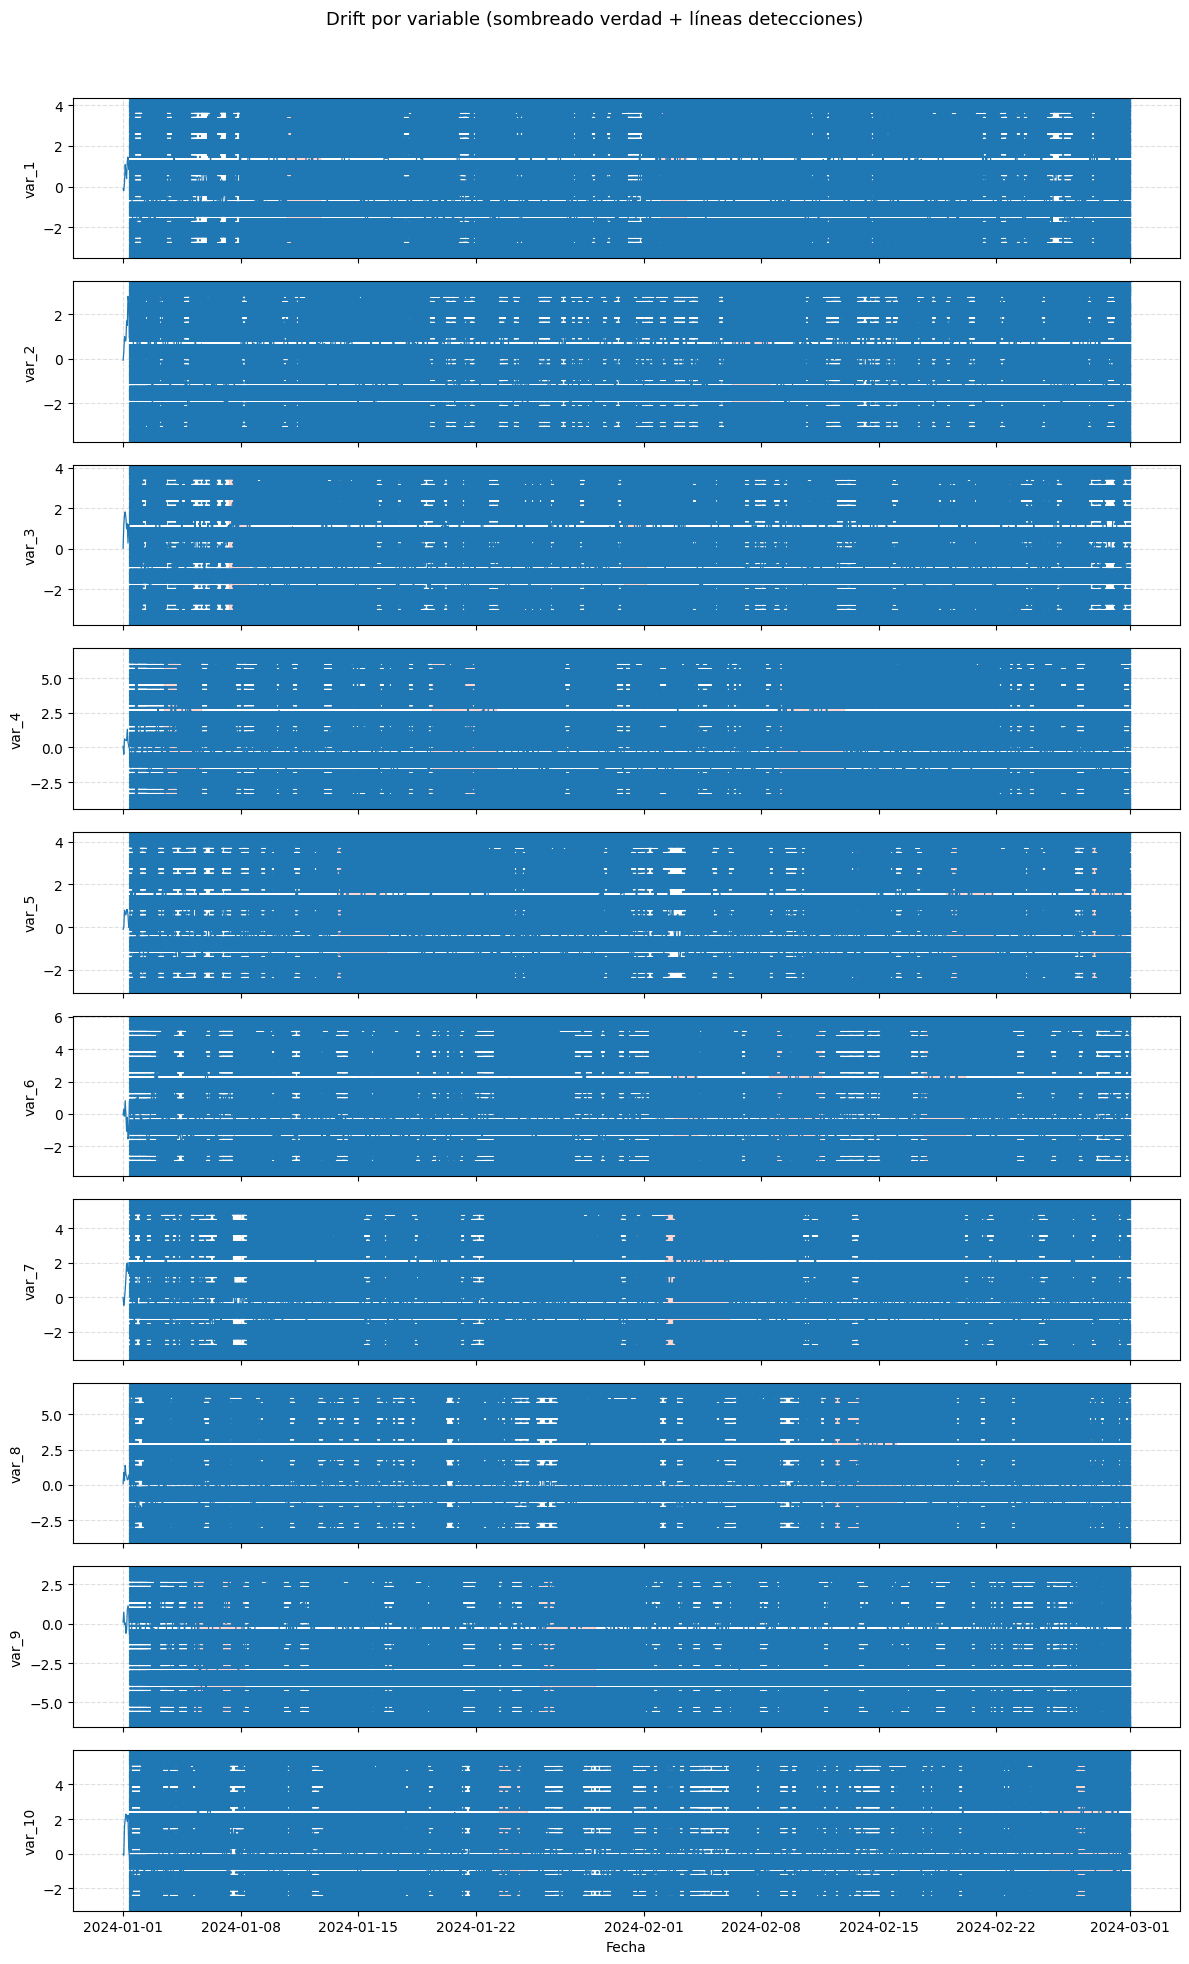

In [9]:
# ==================== Plots de series ====================
def plot_series_with_truth_and_events(df_wide, truth_mask, events_df, vars_to_plot):
    times = pd.to_datetime(df_wide[TIME_COL])
    fig, axes = plt.subplots(len(vars_to_plot), 1, figsize=(12, 2.0*len(vars_to_plot)), sharex=True)
    if len(vars_to_plot)==1:
        axes = [axes]
    dash = [(5,2),(2,2),(7,3),(1,1)]
    for ax, v in zip(axes, vars_to_plot):
        ax.plot(times, df_wide[v], lw=0.9, label=v)
        # sombreado (intervalos contiguos) desde truth_mask[v]
        mask = truth_mask[v].reindex(times.values, fill_value=0).astype(bool).values
        in_drift=False; start=None
        for i in range(len(mask)):
            if mask[i] and not in_drift:
                start = times.iloc[i]; in_drift=True
            elif (not mask[i]) and in_drift:
                ax.axvspan(start, times.iloc[i], color='tomato', alpha=0.25); in_drift=False
        if in_drift:
            ax.axvspan(start, times.iloc[-1], color='tomato', alpha=0.25)

        # líneas por método
        methods = ['ks','mannwhitney','psi','wasserstein']
        style = {m: dash[i%len(dash)] for i,m in enumerate(methods)}
        ev_var = events_df[events_df['variable']==v]
        for m in methods:
            for tdet in pd.to_datetime(ev_var.loc[ev_var['method']==m,'t_end']).sort_values():
                ax.axvline(tdet, linestyle=(0, style[m]), alpha=0.9)

        ax.set_ylabel(v); ax.grid(True, ls='--', alpha=0.4)
    axes[-1].set_xlabel('Fecha')
    fig.suptitle('Drift por variable (sombreado verdad + líneas detecciones)', fontsize=13)
    plt.tight_layout(rect=[0,0,1,0.96]); plt.show()

vars_to_plot = [f'var_{i}' for i in range(1, min(10, len(VALUE_COLS))+1)]
plot_series_with_truth_and_events(df_wide, truth_mask, events_df, vars_to_plot)


## Heatmaps (resolución nativa)
- **Truth** (0/1) a resolución de la serie.
- **Combinado** (0=none, 1=true, 2=pred, 3=both) usando `pred_any`.
- **12 heatmaps** (solo detección) por combinación estrategia×método.

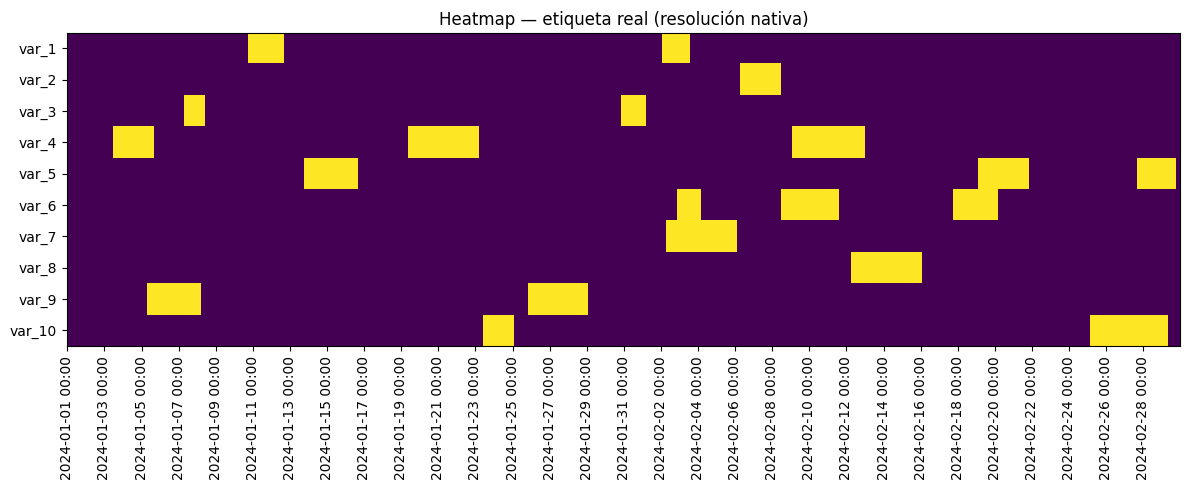

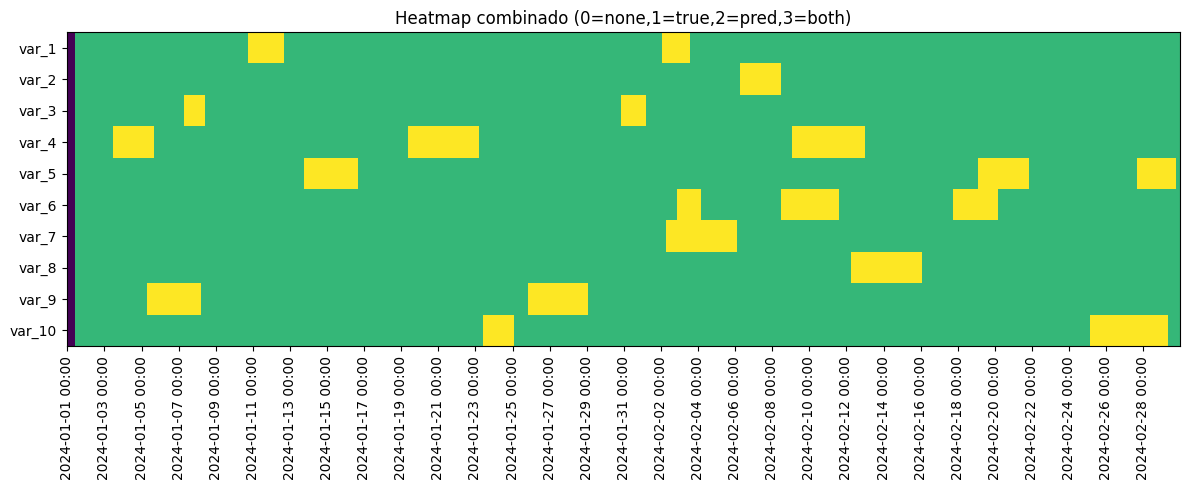

In [10]:
# ==================== Heatmap truth y combinado ====================
def show_heatmap(mat, row_labels, col_times, title, vmax=None):
    plt.figure(figsize=(12, max(4, 0.5*len(row_labels))))
    plt.imshow(mat, aspect='auto', interpolation='nearest', vmin=0, vmax=vmax)
    plt.yticks(range(len(row_labels)), row_labels)
    # Para no saturar el eje x, mostramos marcas cada ~7 días si es H
    idx = pd.to_datetime(col_times)
    step = max(1, len(idx)//30)
    labels = [pd.to_datetime(idx[i]).strftime('%Y-%m-%d %H:%M') for i in range(0, len(idx), step)]
    pos    = list(range(0, len(idx), step))
    plt.xticks(pos, labels, rotation=90)
    plt.title(title)
    plt.tight_layout(); plt.show()

vars_10 = vars_to_plot  # usar las mismas 10
truth_mat = truth_mask[vars_10].T.values  # filas=vars, cols=tiempo
show_heatmap(truth_mat, vars_10, times_unique, 'Heatmap — etiqueta real (resolución nativa)', vmax=1)

combo = truth_mask[vars_10].values + 2*pred_any[vars_10].values
combo = combo.T  # filas=vars
show_heatmap(combo, vars_10, times_unique, 'Heatmap combinado (0=none,1=true,2=pred,3=both)', vmax=3)


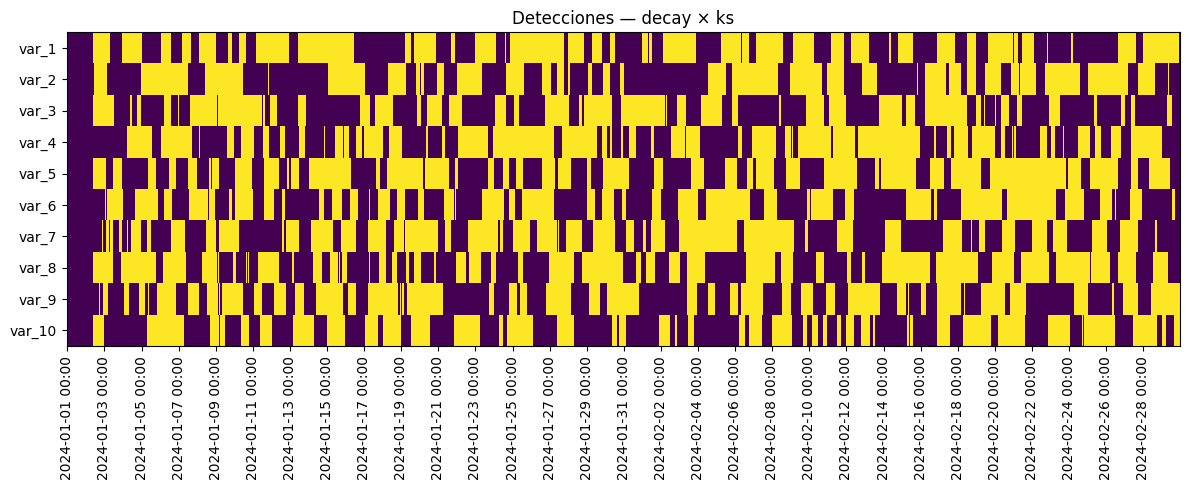

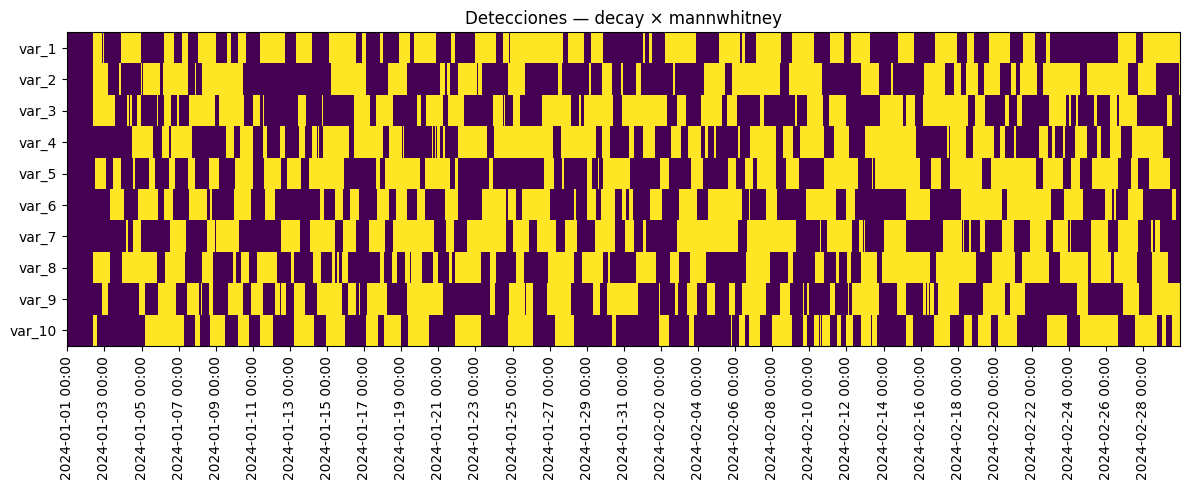

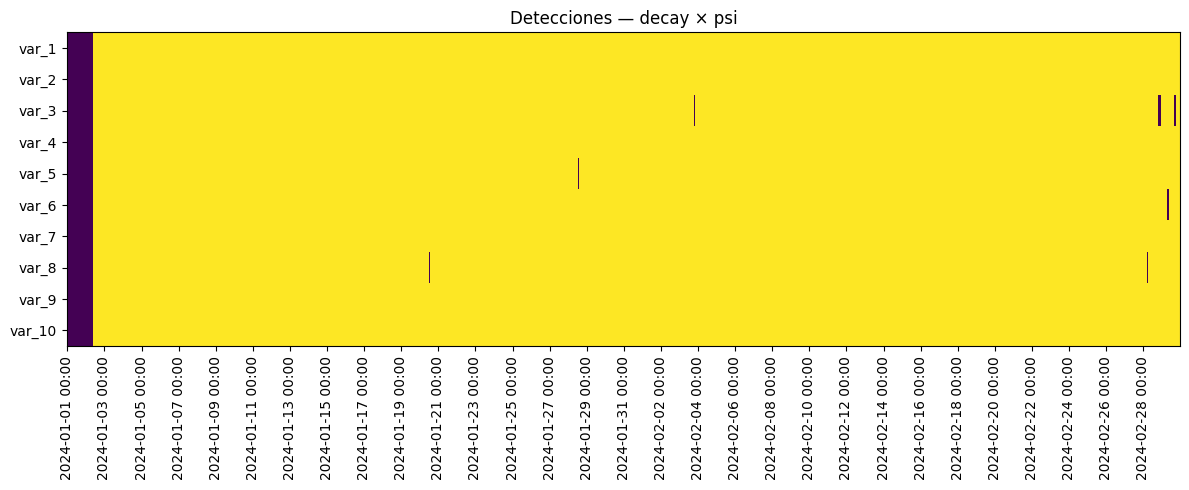

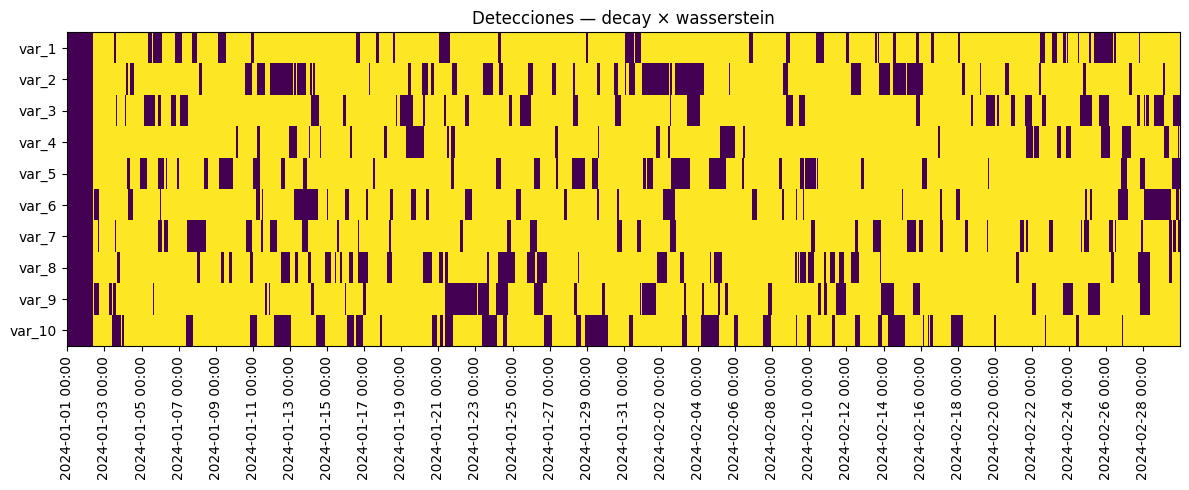

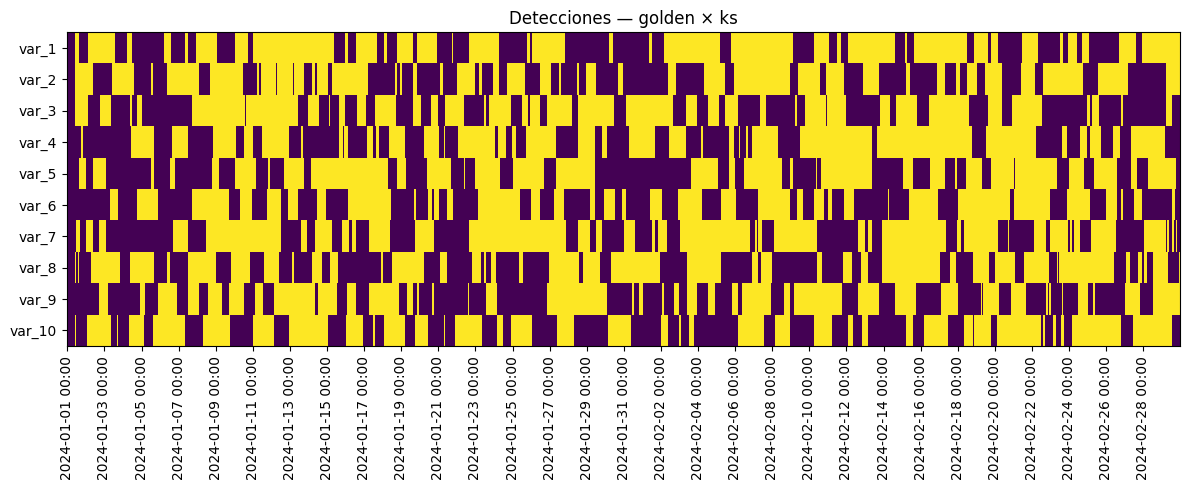

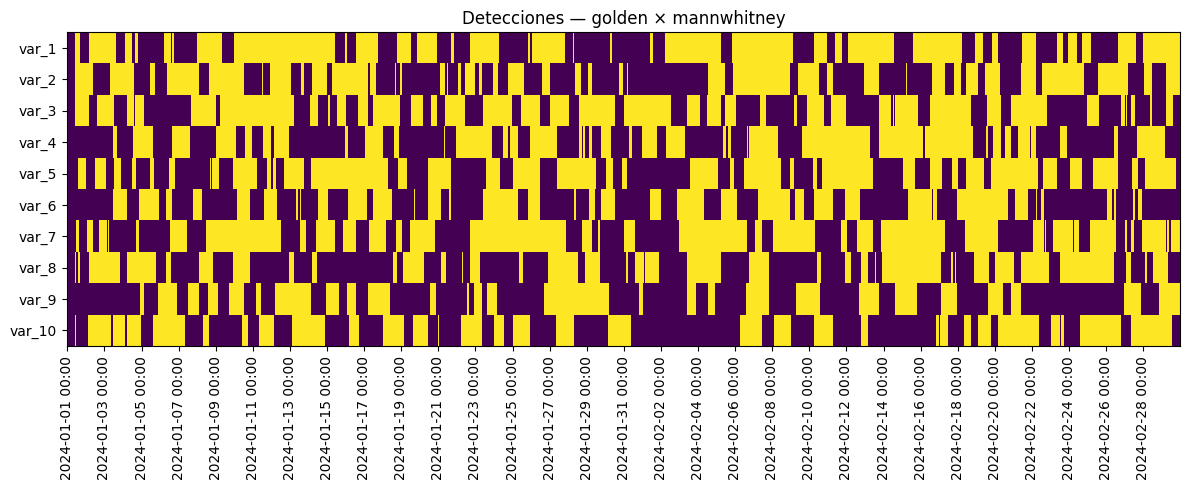

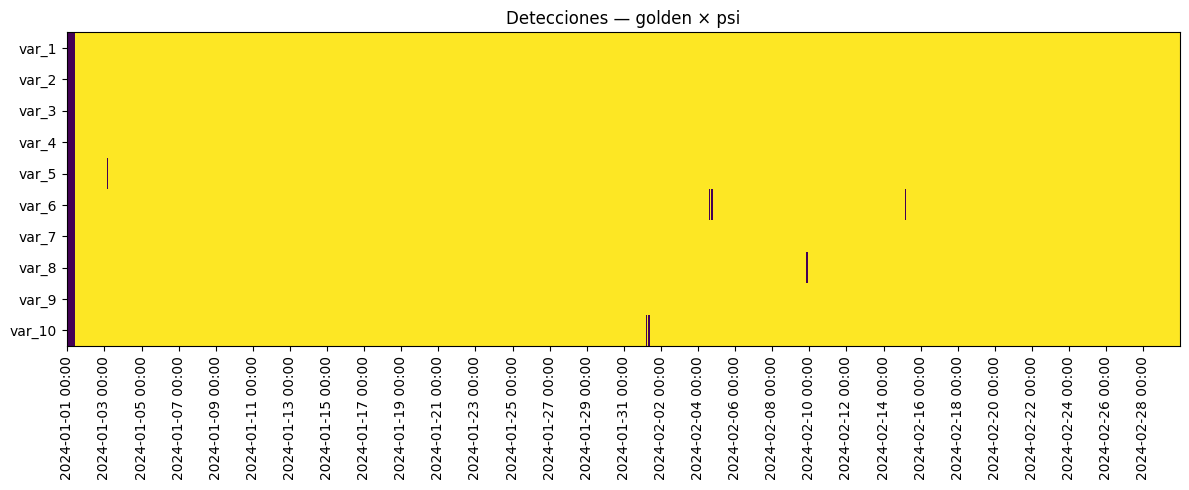

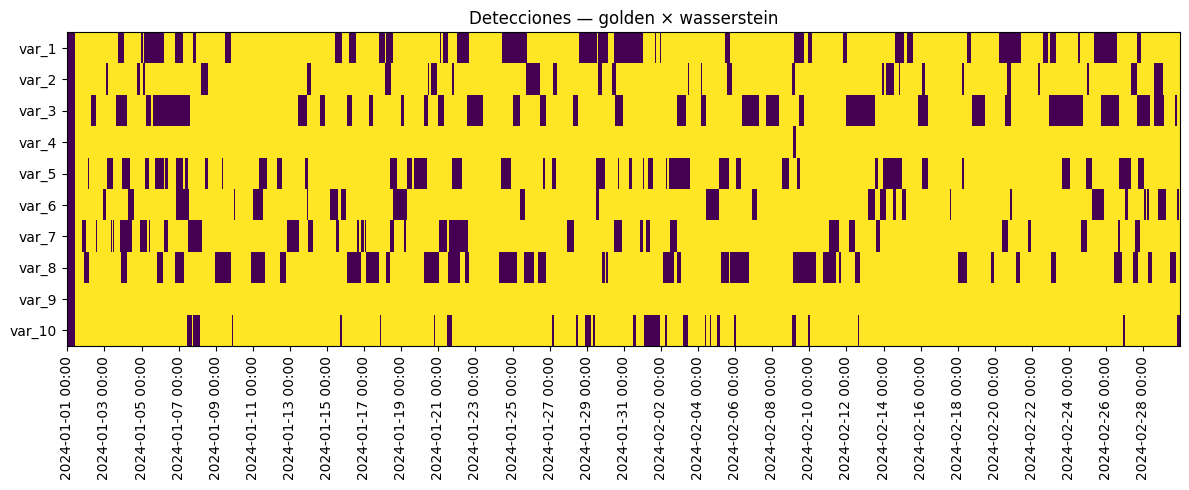

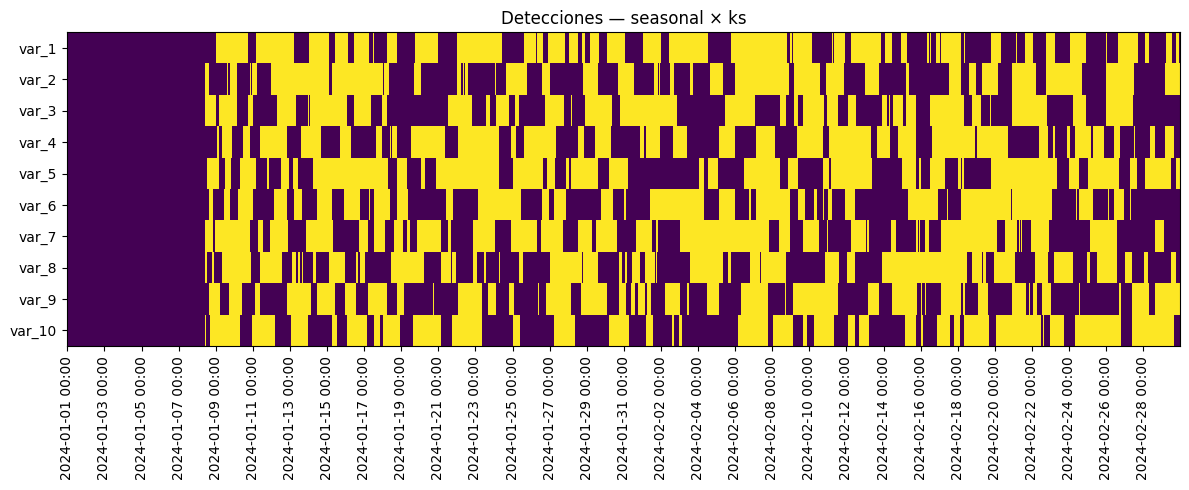

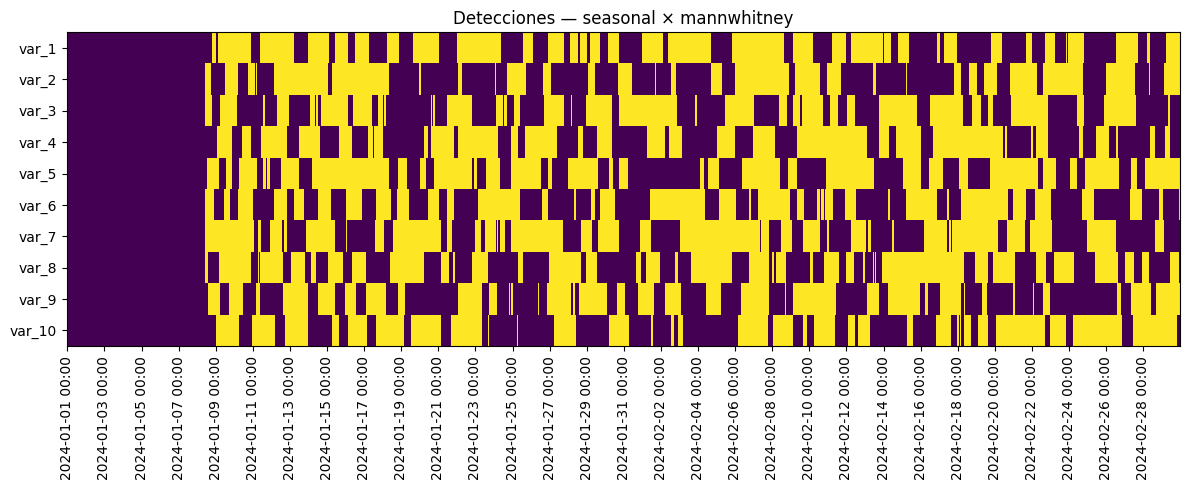

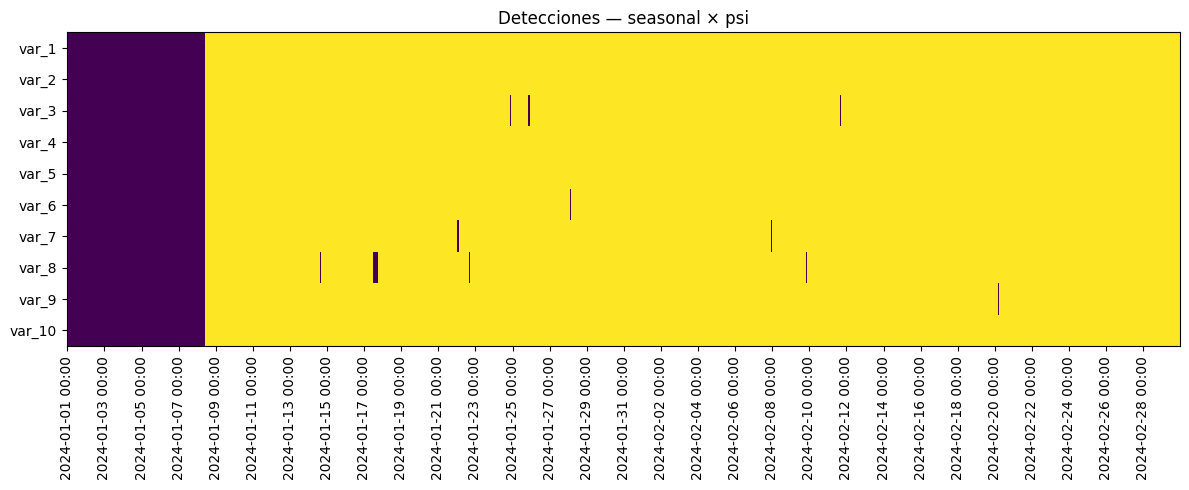

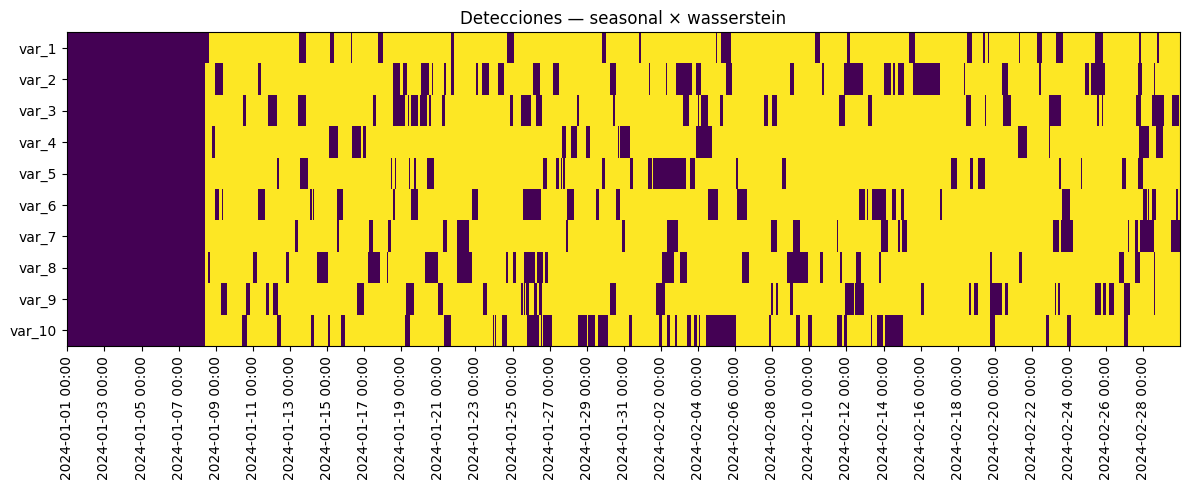

In [11]:
# ==================== 12 heatmaps (solo detección) ====================
for st in STRATEGIES:
    for me in METHODS:
        key = f'{st}__{me}'
        M = pred_masks[key][vars_10].T.values
        show_heatmap(M, vars_10, times_unique, f'Detecciones — {st} × {me}', vmax=1)
